# Does the Bio-response in CaSR Results Happen in Other Results?

Especially HRDPS 10km. Was the bio-response driven by different sets of forcing fields, or resolution?


For CaSR case, see: https://github.com/SalishSeaCast/analysis-junqi/blob/main/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/All_compare_flux.ipynb

## All bio sreults

Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Central_SoG_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Juan_de_Fuca_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Haro_Strait_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Northern_SoG_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Puget_Sound_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Pam_Rocks_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00

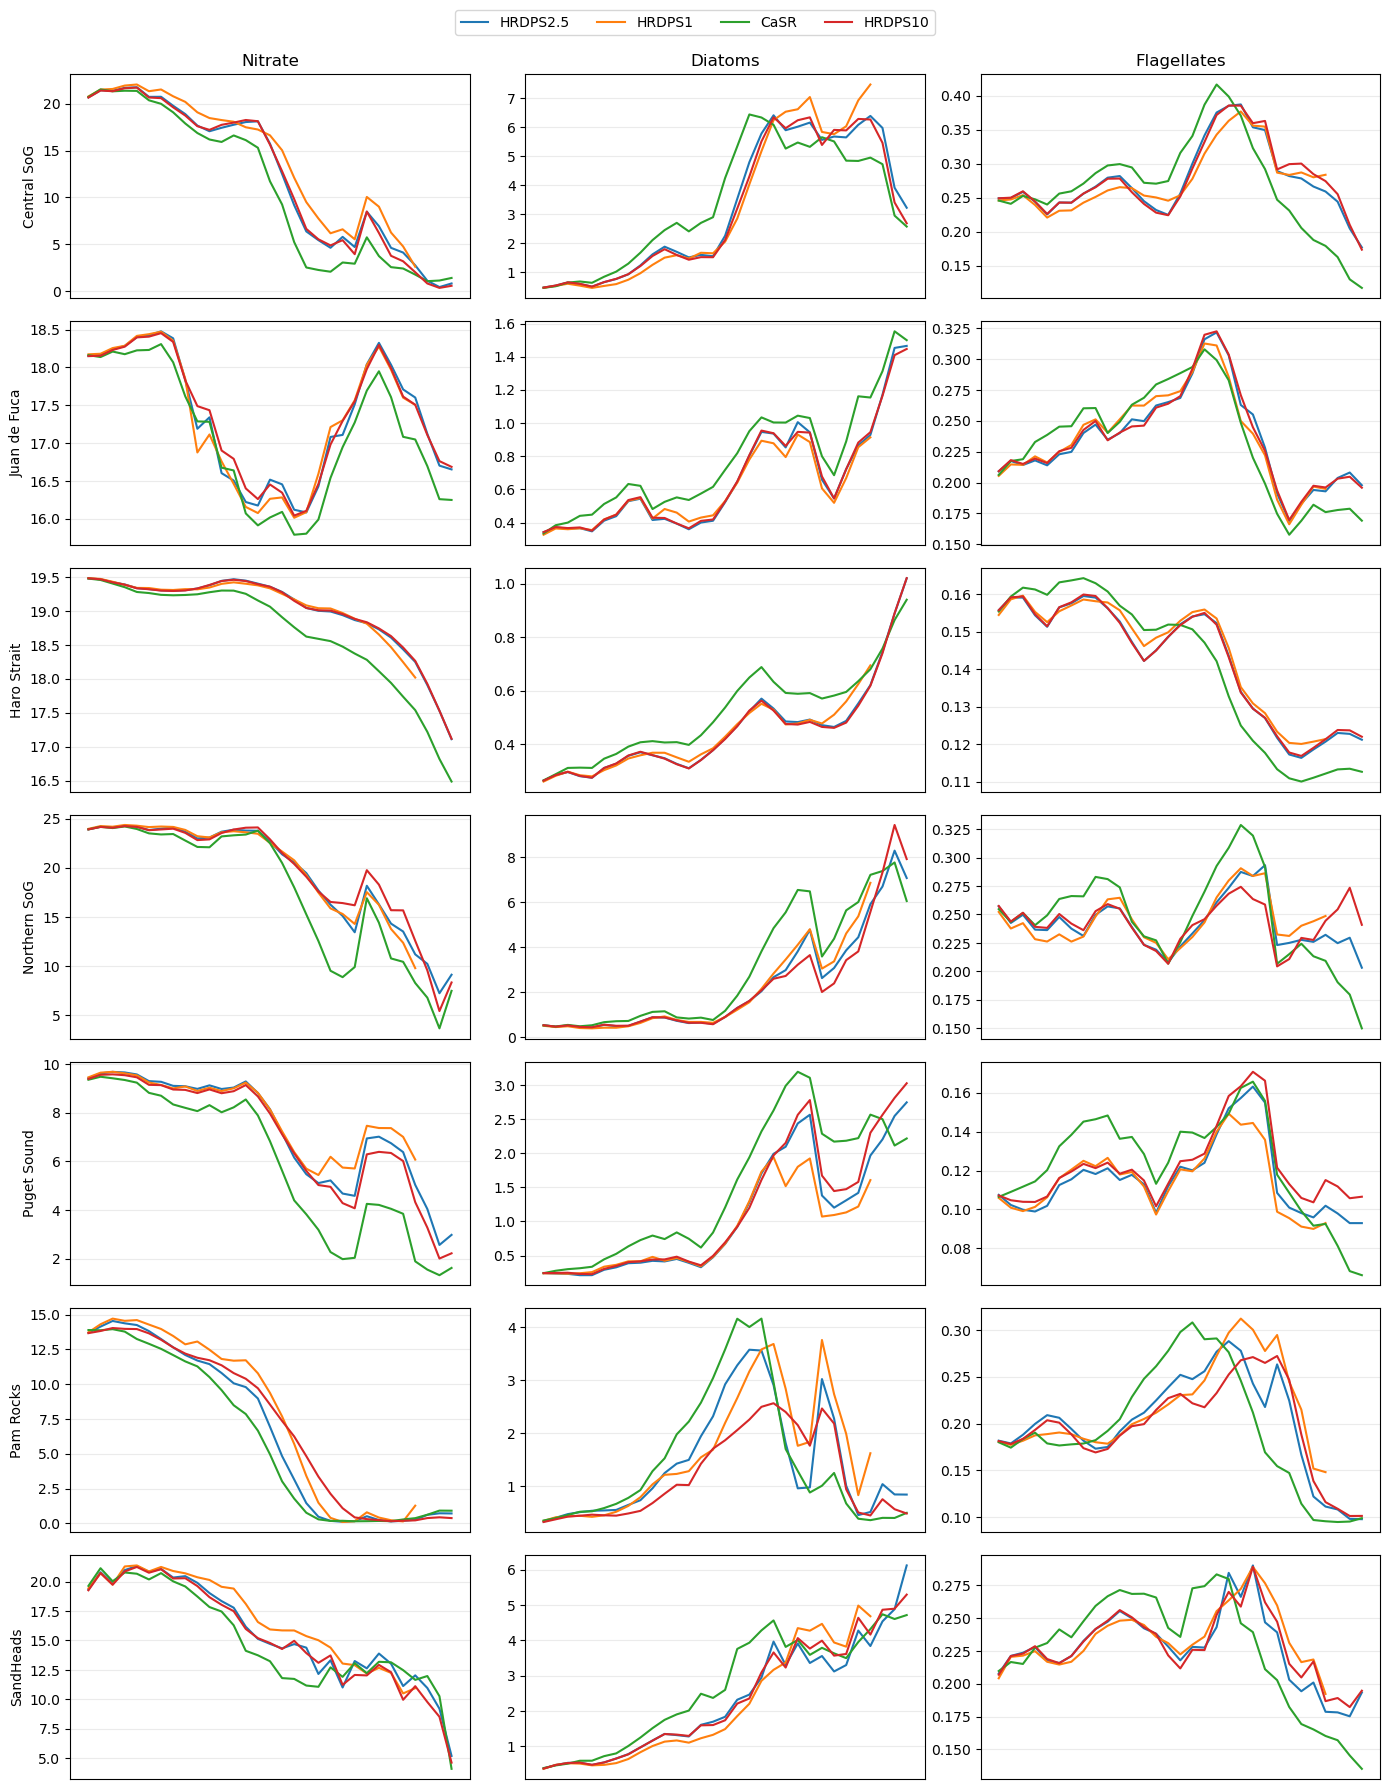

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATH
# ============================================================

DATA_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/biology"
)


# ============================================================
# 2. SETTINGS
# ============================================================

REGIONS = [
    "Central SoG",
    "Juan de Fuca",
    "Haro Strait",
    "Northern SoG",
    "Puget Sound",
    "Pam Rocks",
    "SandHeads",
]

MODELS = [
    "HRDPS2.5",
    "HRDPS1",
    "CaSR",
    "HRDPS10",
]

VARIABLES = [
    ("nitrate_surface", "Nitrate"),
    ("diatoms_surface", "Diatoms"),
    ("flagellates_surface", "Flagellates"),
]


# ============================================================
# 3. HELPERS
# ============================================================

def safe_filename(name):
    return name.replace(" ", "_")


# ============================================================
# 4. PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=len(REGIONS),
    ncols=len(VARIABLES),
    figsize=(14, 18),
)

for row, region in enumerate(REGIONS):

    filename = (
        DATA_DIR /
        f"{safe_filename(region)}_biology.csv"
    )

    print(f"Reading: {filename}")

    df = pd.read_csv(filename)

    # 不管时间，直接按数据点序号画
    x = range(len(df))

    for col, (var_name, var_title) in enumerate(VARIABLES):

        ax = axes[row, col]

        for model in MODELS:

            column_name = f"{model}__{var_name}"

            if column_name not in df.columns:
                print(
                    f"WARNING: missing column: "
                    f"{column_name}"
                )
                continue

            ax.plot(
                x,
                df[column_name],
                label=model,
                linewidth=1.5,
            )

        # 第一行写变量名字
        if row == 0:
            ax.set_title(var_title)

        # 第一列写地点名字
        if col == 0:
            ax.set_ylabel(region)

        # 不显示时间/日期
        ax.set_xticks([])

        ax.grid(alpha=0.25)


# ============================================================
# 5. SHARED LEGEND
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(MODELS),
    bbox_to_anchor=(0.5, 0.995),
)

plt.tight_layout(
    rect=[0, 0, 1, 0.975]
)


# ============================================================
# SHOW
# ============================================================

plt.show()

## HRDPS 10 vs HRDPS 2.5

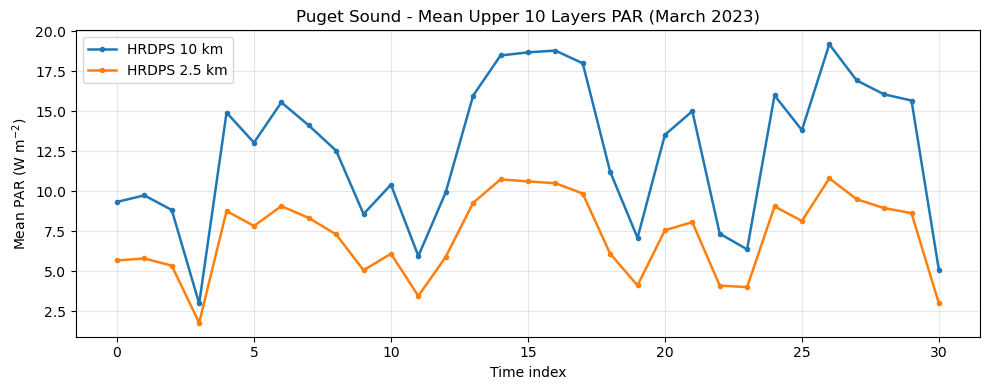

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Files
# ============================================================
path_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

path_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

# ============================================================
# Puget Sound: (j0, j1, i0, i1)
# ============================================================
j0, j1, i0, i1 = 75, 125, 225, 280

casr_ds = xr.open_dataset(path_casr)
hrdps_ds = xr.open_dataset(path_hrdps)

# ============================================================
# Upper 20 layers PAR, all time indices
# ============================================================
casr = casr_ds['PAR'].isel(
    deptht=slice(0, 10),
    y=slice(j0, j1),
    x=slice(i0, i1)
)

hrdps = hrdps_ds['PAR'].isel(
    deptht=slice(0, 20),
    y=slice(j0, j1),
    x=slice(i0, i1)
)

# ============================================================
# Remove zero, negative and NaN values
# ============================================================
casr = casr.where(np.isfinite(casr) & (casr > 0))
hrdps = hrdps.where(np.isfinite(hrdps) & (hrdps > 0))

# ============================================================
# Spatial and vertical mean for each time index
# ============================================================
casr_mean = casr.mean(
    dim=['deptht', 'y', 'x'],
    skipna=True
).values

hrdps_mean = hrdps.mean(
    dim=['deptht', 'y', 'x'],
    skipna=True
).values

# Use index only
time_idx = np.arange(len(casr_mean))

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10, 4))

plt.plot(
    time_idx, casr_mean,
    '-o', label='HRDPS 10 km',
    linewidth=1.8, markersize=3
)

plt.plot(
    time_idx, hrdps_mean,
    '-o', label='HRDPS 2.5 km',
    linewidth=1.8, markersize=3
)

plt.xlabel('Time index')
plt.ylabel('Mean PAR (W m$^{-2}$)')
plt.title('Puget Sound - Mean Upper 10 Layers PAR (March 2023)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

casr_ds.close()
hrdps_ds.close()

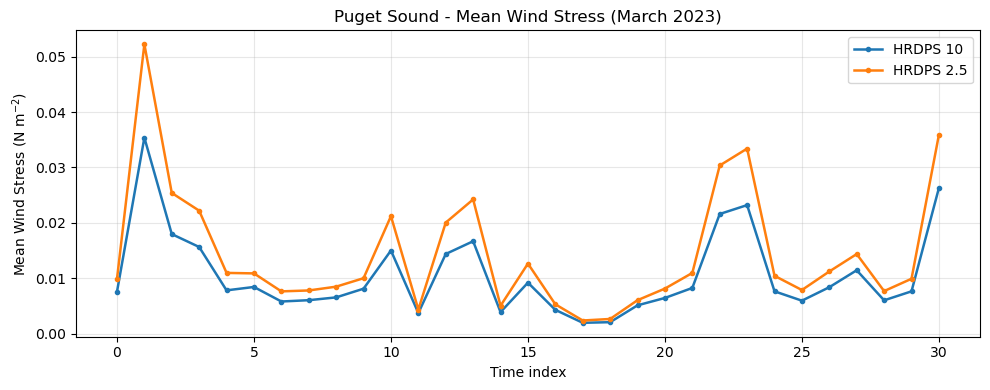

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Files
# ============================================================
path_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)

path_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)

# ============================================================
# Puget Sound: (j0, j1, i0, i1)
# ============================================================
j0, j1, i0, i1 = 75, 125, 225, 280

casr_ds = xr.open_dataset(path_casr)
hrdps_ds = xr.open_dataset(path_hrdps)

# ============================================================
# Wind stress, all time indices
# ============================================================
casr = casr_ds['wind stress'].isel(
    y=slice(j0, j1),
    x=slice(i0, i1)
)

hrdps = hrdps_ds['wind stress'].isel(
    y=slice(j0, j1),
    x=slice(i0, i1)
)

# ============================================================
# Remove invalid values
# ============================================================
casr = casr.where(np.isfinite(casr))
hrdps = hrdps.where(np.isfinite(hrdps))

# ============================================================
# Spatial mean for each time index
# ============================================================
casr_mean = casr.mean(
    dim=['y', 'x'],
    skipna=True
).values

hrdps_mean = hrdps.mean(
    dim=['y', 'x'],
    skipna=True
).values

# Use index only
time_idx = np.arange(len(casr_mean))

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10, 4))

plt.plot(
    time_idx, casr_mean,
    '-o', label='HRDPS 10',
    linewidth=1.8, markersize=3
)

plt.plot(
    time_idx, hrdps_mean,
    '-o', label='HRDPS 2.5',
    linewidth=1.8, markersize=3
)

plt.xlabel('Time index')
plt.ylabel('Mean Wind Stress (N m$^{-2}$)')
plt.title('Puget Sound - Mean Wind Stress (March 2023)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

casr_ds.close()
hrdps_ds.close()

**Why doesn't `HRDPS 10km` have similar nitrate and plankton curves?**